# 03 - Advanced: Processors, DAG Analysis & Flow Optimization

This notebook covers advanced py2dataiku features:

1. **ProcessorCatalog** - Exploring the 100+ available Dataiku processors
2. **Processor Demos** - Building PrepareSteps for key processor types
3. **PrepareSettings** - Composing multi-step Prepare recipes
4. **FlowGraph (DAG)** - Topological sort, cycle detection, subgraph discovery
5. **FlowOptimizer** - Merging recipes, removing orphans, optimization results
6. **Flow Validation** - Structural validation with errors, warnings, info
7. **Column Lineage** - Tracing columns through the flow

In [1]:
import sys
sys.path.insert(0, "../..")

## 1. ProcessorCatalog

The `ProcessorCatalog` provides metadata for all available Dataiku Prepare recipe processors,
including parameter requirements and example configurations.

In [2]:
from py2dataiku.mappings.processor_catalog import ProcessorCatalog

# List all available processors
all_processors = ProcessorCatalog.list_processors()
print(f"Total processors available: {len(all_processors)}")
print(f"\nFirst 15 processors: {all_processors[:15]}")

Total processors available: 120

First 15 processors: ['ColumnRenamer', 'ColumnCopier', 'ColumnsSelector_delete', 'ColumnsSelector', 'ColumnReorder', 'ColumnsConcat', 'FillEmptyWithValue', 'RemoveRowsOnEmpty', 'UpDownFill', 'FillEmptyWithComputedValue', 'ImputeWithML', 'StringTransformer', 'FindReplace', 'PatternExtract', 'ColumnsSplitter']


In [3]:
# List all processor categories
categories = ProcessorCatalog.list_categories()
print("Processor categories:")
for cat in categories:
    processors_in_cat = ProcessorCatalog.list_processors(category=cat)
    print(f"  {cat}: {len(processors_in_cat)} processors")

Processor categories:
  Advanced: 2 processors
  Array/JSON: 9 processors
  Categorical: 9 processors
  Column Manipulation: 6 processors
  Computed Columns: 6 processors
  Conditional Logic: 2 processors
  Custom: 1 processors
  Data Extraction: 2 processors
  Date/Time: 6 processors
  Filtering: 9 processors
  Flagging: 5 processors
  Geographic: 7 processors
  Missing Values: 5 processors
  Numeric Operations: 14 processors
  Reshaping: 3 processors
  Row Operations: 4 processors
  String Operations: 21 processors
  Type Conversion: 6 processors
  Value Manipulation: 3 processors


In [4]:
# Get detailed info about a specific processor
info = ProcessorCatalog.get_processor("StringTransformer")
print(f"Name: {info.name}")
print(f"Category: {info.category}")
print(f"Description: {info.description}")
print(f"Required params: {info.required_params}")
print(f"Optional params: {info.optional_params}")
print(f"Example params: {info.example_params}")

Name: StringTransformer
Category: String Operations
Description: Transform string values (uppercase, lowercase, trim, etc.)
Required params: ['column', 'mode']
Optional params: []
Example params: {'column': 'name', 'mode': 'TO_LOWER'}


In [5]:
# Convenience methods for parameter lookup
print("Required params for Binner:", ProcessorCatalog.get_required_params("Binner"))
print("Example for Formula:", ProcessorCatalog.get_example("Formula"))
print("Example for IfThenElse:", ProcessorCatalog.get_example("IfThenElse"))

Required params for Binner: ['column', 'mode']
Example for Formula: {'outputColumn': 'total', 'expression': 'price * quantity'}
Example for IfThenElse: {'column': 'age', 'condition': 'val >= 18', 'thenValue': 'adult', 'elseValue': 'minor', 'outputColumn': 'age_group'}


## 2. Processor Demos with PrepareStep

Each processor type maps to a `PrepareStep`. Below we demonstrate 15+ key processors
with both the pandas equivalent and the corresponding `PrepareStep` construction.

In [6]:
from py2dataiku.models.prepare_step import (
    PrepareStep,
    ProcessorType,
    StringTransformerMode,
    NumericalTransformerMode,
    FilterMatchMode,
)

# --- 1. COLUMN_RENAMER ---
# pandas: df.rename(columns={"old_col": "new_col"})
step_rename = PrepareStep.rename_columns({"old_col": "new_col", "amt": "amount"})
print("COLUMN_RENAMER:", step_rename)
print("  Description:", step_rename.get_description())
print()

COLUMN_RENAMER: PrepareStep(type=ColumnRenamer, params={'renamings': [{'from': 'old_col', 'to': 'new_col'}, {'from': 'amt', 'to': 'amount'}]})
  Description: Rename columns: old_col -> new_col, amt -> amount



In [7]:
# --- 2. FILL_EMPTY_WITH_VALUE ---
# pandas: df["score"].fillna(0)
step_fill = PrepareStep.fill_empty(column="score", value=0)
print("FILL_EMPTY_WITH_VALUE:", step_fill)
print("  Description:", step_fill.get_description())
print()

# --- 3. REMOVE_ROWS_ON_EMPTY ---
# pandas: df.dropna(subset=["email", "name"])
step_dropna = PrepareStep.remove_rows_on_empty(columns=["email", "name"])
print("REMOVE_ROWS_ON_EMPTY:", step_dropna)
print("  Description:", step_dropna.get_description())

FILL_EMPTY_WITH_VALUE: PrepareStep(type=FillEmptyWithValue, params={'column': 'score', 'value': '0'})
  Description: Fill empty values in 'score' with '0'

REMOVE_ROWS_ON_EMPTY: PrepareStep(type=RemoveRowsOnEmpty, params={'columns': ['email', 'name'], 'keep': False})
  Description: Remove rows with empty values in: email, name


In [8]:
# --- 4. STRING_TRANSFORMER ---
# pandas: df["name"].str.upper()
step_upper = PrepareStep.string_transform(
    column="name",
    mode=StringTransformerMode.UPPERCASE,
)
print("STRING_TRANSFORMER (UPPERCASE):", step_upper)
print("  Description:", step_upper.get_description())
print()

# pandas: df["name"].str.strip()
step_trim = PrepareStep.string_transform(
    column="name",
    mode=StringTransformerMode.TRIM,
)
print("STRING_TRANSFORMER (TRIM):", step_trim)
print()

# Show all available string transformer modes
print("Available StringTransformerMode values:")
for mode in list(StringTransformerMode)[:10]:
    print(f"  {mode.name} -> {mode.value}")

STRING_TRANSFORMER (UPPERCASE): PrepareStep(type=StringTransformer, params={'column': 'name', 'mode': 'TO_UPPER'})
  Description: Transform string 'name' with mode TO_UPPER

STRING_TRANSFORMER (TRIM): PrepareStep(type=StringTransformer, params={'column': 'name', 'mode': 'TRIM'})

Available StringTransformerMode values:
  UPPERCASE -> TO_UPPER
  LOWERCASE -> TO_LOWER
  TITLECASE -> TITLECASE
  CAPITALIZE -> CAPITALIZE
  SWAPCASE -> SWAPCASE
  TRIM -> TRIM
  TRIM_LEFT -> TRIM_LEFT
  TRIM_RIGHT -> TRIM_RIGHT
  NORMALIZE_WHITESPACE -> NORMALIZE_WHITESPACE
  REMOVE_WHITESPACE -> REMOVE_WHITESPACE


In [9]:
# --- 5. TYPE_SETTER ---
# pandas: df["id"].astype(int)
step_type = PrepareStep.set_type(column="id", target_type="bigint")
print("TYPE_SETTER:", step_type)
print("  Description:", step_type.get_description())
print()

# --- 6. DATE_PARSER ---
# pandas: pd.to_datetime(df["date_str"], format="%Y-%m-%d")
step_date = PrepareStep.parse_date(column="date_str", formats=["yyyy-MM-dd"])
print("DATE_PARSER:", step_date)

TYPE_SETTER: PrepareStep(type=TypeSetter, params={'column': 'id', 'type': 'bigint'})
  Description: Set type of 'id' to bigint

DATE_PARSER: PrepareStep(type=DateParser, params={'column': 'date_str', 'formats': ['yyyy-MM-dd']})


In [10]:
# --- 7. BINNER ---
# pandas: pd.cut(df["age"], bins=[0, 18, 35, 50, 100])
step_binner = PrepareStep(
    processor_type=ProcessorType.BINNER,
    params={
        "column": "age",
        "mode": "FIXED_BINS",
        "bins": [0, 18, 35, 50, 100],
    },
)
print("BINNER:", step_binner)
print("  Dict:", step_binner.to_dict())
print()

# --- 8. FILTER_ON_VALUE ---
# pandas: df[df["status"] == "active"]
step_filter = PrepareStep.filter_on_value(
    column="status",
    values=["active"],
    matching_mode="EQUALS",
    keep=True,
)
print("FILTER_ON_VALUE:", step_filter)

BINNER: PrepareStep(type=Binner, params={'column': 'age', 'mode': 'FIXED_BINS', 'bins': [0, 18, 35, 50, 100]})
  Dict: {'metaType': 'PROCESSOR', 'type': 'Binner', 'disabled': False, 'params': {'column': 'age', 'mode': 'FIXED_BINS', 'bins': [0, 18, 35, 50, 100]}}

FILTER_ON_VALUE: PrepareStep(type=FilterOnValue, params={'column': 'status', 'values': ['active'], 'matchingMode': 'EQUALS', 'keep': True})


In [11]:
# --- 9. ONE_HOT_ENCODER ---
# pandas: pd.get_dummies(df, columns=["category"])
step_ohe = PrepareStep(
    processor_type=ProcessorType.ONE_HOT_ENCODER,
    params={"column": "category"},
)
print("ONE_HOT_ENCODER:", step_ohe)
print()

# --- 10. FORMULA ---
# pandas: df["total"] = df["price"] * df["quantity"]
step_formula = PrepareStep(
    processor_type=ProcessorType.FORMULA,
    params={
        "outputColumn": "total",
        "expression": "price * quantity",
    },
)
print("FORMULA:", step_formula)

ONE_HOT_ENCODER: PrepareStep(type=OneHotEncoder, params={'column': 'category'})

FORMULA: PrepareStep(type=Formula, params={'outputColumn': 'total', 'expression': 'price * quantity'})


In [12]:
# --- 11. IF_THEN_ELSE ---
# pandas: df["age_group"] = np.where(df["age"] >= 18, "adult", "minor")
step_ite = PrepareStep.if_then_else(
    column="age",
    condition="val >= 18",
    then_value="adult",
    else_value="minor",
    output_column="age_group",
)
print("IF_THEN_ELSE:", step_ite)
print("  Dict:", step_ite.to_dict())
print()

# --- 12. SWITCH_CASE ---
# pandas: df["status"].map({"A": "Active", "I": "Inactive"})
step_switch = PrepareStep.switch_case(
    column="status",
    cases={"A": "Active", "I": "Inactive", "P": "Pending"},
    default_value="Unknown",
    output_column="status_label",
)
print("SWITCH_CASE:", step_switch)

IF_THEN_ELSE: PrepareStep(type=IfThenElse, params={'column': 'age', 'condition': 'val >= 18', 'thenValue': 'adult', 'elseValue': 'minor', 'outputColumn': 'age_group'})
  Dict: {'metaType': 'PROCESSOR', 'type': 'IfThenElse', 'disabled': False, 'params': {'column': 'age', 'condition': 'val >= 18', 'thenValue': 'adult', 'elseValue': 'minor', 'outputColumn': 'age_group'}}

SWITCH_CASE: PrepareStep(type=SwitchCase, params={'column': 'status', 'cases': [{'value': 'A', 'output': 'Active'}, {'value': 'I', 'output': 'Inactive'}, {'value': 'P', 'output': 'Pending'}], 'defaultValue': 'Unknown', 'outputColumn': 'status_label'})


In [13]:
# --- 13. COLUMN_DELETER ---
# pandas: df.drop(columns=["temp_col", "debug_col"])
step_delete = PrepareStep.delete_columns(["temp_col", "debug_col"])
print("COLUMN_DELETER:", step_delete)
print("  Description:", step_delete.get_description())
print()

# --- 14. REMOVE_DUPLICATES ---
# pandas: df.drop_duplicates(subset=["id"])
step_dedup = PrepareStep.remove_duplicates(columns=["id"])
print("REMOVE_DUPLICATES:", step_dedup)
print("  Description:", step_dedup.get_description())

COLUMN_DELETER: PrepareStep(type=ColumnsSelector, params={'columns': ['temp_col', 'debug_col'], 'keep': False, 'mode': 'remove'})
  Description: Delete columns: temp_col, debug_col

REMOVE_DUPLICATES: PrepareStep(type=RemoveDuplicates, params={'columns': ['id']})
  Description: Remove duplicates on columns: id


In [14]:
# --- 15. REGEXP_EXTRACTOR ---
# pandas: df["zip"] = df["address"].str.extract(r"(\d{5})")
step_regex = PrepareStep.regexp_extract(
    column="address",
    pattern=r"(\d{5})",
    output_columns=["zip_code"],
)
print("REGEXP_EXTRACTOR:", step_regex)
print()

# --- 16. NUMERICAL_TRANSFORMER ---
# pandas: df["amount"] = df["amount"] * 100
step_num = PrepareStep(
    processor_type=ProcessorType.NUMERICAL_TRANSFORMER,
    params={"column": "amount", "mode": "MULTIPLY", "value": 100},
)
print("NUMERICAL_TRANSFORMER:", step_num)
print()

# --- 17. TRANSLATE_VALUES ---
# pandas: df["country"].replace({"US": "United States", "UK": "United Kingdom"})
step_translate = PrepareStep.translate_values(
    column="country_code",
    translations={"US": "United States", "UK": "United Kingdom", "FR": "France"},
)
print("TRANSLATE_VALUES:", step_translate)

REGEXP_EXTRACTOR: PrepareStep(type=PatternExtract, params={'column': 'address', 'pattern': '(\\d{5})', 'outputColumns': ['zip_code']})

NUMERICAL_TRANSFORMER: PrepareStep(type=NumericalTransformer, params={'column': 'amount', 'mode': 'MULTIPLY', 'value': 100})

TRANSLATE_VALUES: PrepareStep(type=TranslateValues, params={'column': 'country_code', 'translations': [{'from': 'US', 'to': 'United States'}, {'from': 'UK', 'to': 'United Kingdom'}, {'from': 'FR', 'to': 'France'}]})


In [15]:
# PrepareStep serialization round-trip
original = PrepareStep.if_then_else(
    column="score", condition="val > 90",
    then_value="A", else_value="B", output_column="grade",
)
as_dict = original.to_dict()
restored = PrepareStep.from_dict(as_dict)
print("Original:", original)
print("Dict:    ", as_dict)
print("Restored:", restored)
print("Match:   ", original.processor_type == restored.processor_type
      and original.params == restored.params)

Original: PrepareStep(type=IfThenElse, params={'column': 'score', 'condition': 'val > 90', 'thenValue': 'A', 'elseValue': 'B', 'outputColumn': 'grade'})
Dict:     {'metaType': 'PROCESSOR', 'type': 'IfThenElse', 'disabled': False, 'params': {'column': 'score', 'condition': 'val > 90', 'thenValue': 'A', 'elseValue': 'B', 'outputColumn': 'grade'}}
Restored: PrepareStep(type=IfThenElse, params={'column': 'score', 'condition': 'val > 90', 'thenValue': 'A', 'elseValue': 'B', 'outputColumn': 'grade'})
Match:    True


### String Accessor Processors

The AST analyzer now maps `.str.upper()`, `.str.lower()`, `.str.strip()` to `STRING_TRANSFORMER`,
`.str.replace()` to `FIND_REPLACE`, and `.str.extract()` to `REGEXP_EXTRACTOR` processors.
These can be built directly using `PrepareStep` factory methods.

In [16]:
# The AST analyzer recognizes string accessor methods and maps them to processors.
# Demonstrate the mapping from pandas string methods to Dataiku processors:
from py2dataiku.parser.ast_analyzer import CodeAnalyzer

str_code = """
import pandas as pd
df = pd.read_csv('data.csv')
df['name'] = df['name'].str.upper()
df['email'] = df['email'].str.lower()
df['city'] = df['city'].str.strip()
df['desc'] = df['desc'].str.replace('old', 'new')
df['zip'] = df['address'].str.extract(r'(\\d{5})')
"""

analyzer = CodeAnalyzer()
transformations = analyzer.analyze(str_code)

print("String accessor detection results:")
for t in transformations:
    if t.transformation_type.value == "string_transform":
        processor = t.suggested_processor or "StringTransformer"
        print(f"  Column: {t.parameters.get('column', t.columns)}")
        print(f"  Mode:   {t.parameters.get('mode', 'N/A')}")
        print(f"  Processor: {processor}")
        if t.parameters.get("find"):
            print(f"  Find/Replace: '{t.parameters['find']}' -> '{t.parameters['replace']}'")
        if t.parameters.get("pattern"):
            print(f"  Pattern: {t.parameters['pattern']}")
        print()

String accessor detection results:
  Column: name
  Mode:   TO_UPPER
  Processor: StringTransformer

  Column: email
  Mode:   TO_LOWER
  Processor: StringTransformer

  Column: city
  Mode:   TRIM
  Processor: StringTransformer

  Column: desc
  Mode:   N/A
  Processor: FindReplace
  Find/Replace: 'old' -> 'new'

  Column: address
  Mode:   N/A
  Processor: RegexpExtractor
  Pattern: (\d{5})



In [17]:
# Build the equivalent PrepareSteps directly for each string operation
# .str.upper() -> STRING_TRANSFORMER (UPPERCASE)
step_upper = PrepareStep.string_transform("name", StringTransformerMode.UPPERCASE)
# .str.lower() -> STRING_TRANSFORMER (LOWERCASE)
step_lower = PrepareStep.string_transform("email", StringTransformerMode.LOWERCASE)
# .str.strip() -> STRING_TRANSFORMER (TRIM)
step_trim = PrepareStep.string_transform("city", StringTransformerMode.TRIM)
# .str.replace() -> FIND_REPLACE
step_replace = PrepareStep(
    processor_type=ProcessorType.FIND_REPLACE,
    params={"column": "desc", "find": "old", "replace": "new"},
)
# .str.extract() -> REGEXP_EXTRACTOR
step_extract = PrepareStep.regexp_extract(
    column="address", pattern=r"(\d{5})", output_columns=["zip"],
)

print("String accessor -> Dataiku processor mapping:")
for label, step in [
    (".str.upper()", step_upper),
    (".str.lower()", step_lower),
    (".str.strip()", step_trim),
    (".str.replace()", step_replace),
    (".str.extract()", step_extract),
]:
    print(f"  {label:<20s} -> {step.processor_type.value}: {step.params}")

String accessor -> Dataiku processor mapping:
  .str.upper()         -> StringTransformer: {'column': 'name', 'mode': 'TO_UPPER'}
  .str.lower()         -> StringTransformer: {'column': 'email', 'mode': 'TO_LOWER'}
  .str.strip()         -> StringTransformer: {'column': 'city', 'mode': 'TRIM'}
  .str.replace()       -> FindReplace: {'column': 'desc', 'find': 'old', 'replace': 'new'}
  .str.extract()       -> PatternExtract: {'column': 'address', 'pattern': '(\\d{5})', 'outputColumns': ['zip']}


### Column Selection: df[['a','b']] maps to COLUMNS_SELECTOR

Selecting a subset of columns with `df[['a','b']]` now correctly maps to a
`COLUMNS_SELECTOR` processor within a Prepare recipe, not to a SPLIT recipe.

In [18]:
# Column selection: df[['a','b']] -> COLUMNS_SELECTOR (not SPLIT)
from py2dataiku import convert, RecipeType

col_select_code = """
import pandas as pd
df = pd.read_csv('data.csv')
selected = df[['name', 'email', 'age']]
"""

flow = convert(col_select_code)
print("df[['a','b']] generates a Prepare recipe with COLUMNS_SELECTOR:")
for recipe in flow.recipes:
    print(f"  Recipe: {recipe.name} ({recipe.recipe_type.value})")
    if recipe.steps:
        for step in recipe.steps:
            print(f"    Processor: {step.processor_type.value}")
            print(f"    Params:    {step.params}")

df[['a','b']] generates a Prepare recipe with COLUMNS_SELECTOR:
  Recipe: prepare_1 (prepare)
    Processor: ColumnsSelector
    Params:    {'columns': ['name', 'email', 'age'], 'keep': True, 'mode': 'keep'}


### Groupby Dict Aggregation Parsing

`df.groupby('key').agg({'col': 'func'})` now correctly populates the aggregation list
with the proper column names and Dataiku aggregation functions.

In [19]:
# Groupby with dict aggregations -- aggregation list is now populated correctly
groupby_code = """
import pandas as pd
df = pd.read_csv('orders.csv')
result = df.groupby('category').agg({'amount': 'sum', 'quantity': 'mean', 'order_id': 'count'})
"""

flow = convert(groupby_code)
print("Groupby dict aggregation parsing:")
for recipe in flow.recipes:
    if recipe.recipe_type == RecipeType.GROUPING:
        print(f"  Group keys: {recipe.group_keys}")
        print(f"  Aggregations ({len(recipe.aggregations)}):")
        for agg in recipe.aggregations:
            print(f"    {agg.column} -> {agg.function}")

Groupby dict aggregation parsing:
  Group keys: ['category']
  Aggregations (3):
    amount -> SUM
    quantity -> AVG
    order_id -> COUNT


### Column Detection: fillna() and astype() with Subscripts

`df['col'].fillna(0)` and `df['col'].astype(int)` now correctly extract the column
name from the subscript expression, producing accurate processor parameters.

In [20]:
# fillna()/astype() with subscripts now extract correct column names
column_detect_code = """
import pandas as pd
df = pd.read_csv('data.csv')
df['revenue'] = df['revenue'].fillna(0)
df['age'] = df['age'].astype(int)
df['price'] = df['price'].fillna(99.99)
"""

flow = convert(column_detect_code)
print("Column detection from subscript expressions:")
for recipe in flow.recipes:
    if recipe.steps:
        for step in recipe.steps:
            print(f"  {step.processor_type.value}:")
            print(f"    column = {step.params.get('column', 'N/A')}")
            if 'value' in step.params:
                print(f"    value  = {step.params['value']}")
            if 'type' in step.params:
                print(f"    type   = {step.params['type']}")

Column detection from subscript expressions:
  FillEmptyWithValue:
    column = revenue
    value  = 0
  TypeSetter:
    column = age
    type   = int
  FillEmptyWithValue:
    column = price
    value  = 99.99


## 3. PrepareSettings - Multi-Step Prepare Recipes

`PrepareSettings` composes multiple `PrepareStep` objects into a single recipe configuration.
This is how Dataiku's Prepare recipe works: an ordered list of transformation steps.

In [21]:
from py2dataiku.models.recipe_settings import PrepareSettings
from py2dataiku.models.dataiku_recipe import DataikuRecipe, RecipeType

# Build a multi-step cleaning pipeline as a single Prepare recipe
cleaning_steps = [
    PrepareStep.remove_rows_on_empty(columns=["email"]),
    PrepareStep.string_transform("name", StringTransformerMode.TRIM),
    PrepareStep.string_transform("email", StringTransformerMode.LOWERCASE),
    PrepareStep.fill_empty("age", 0),
    PrepareStep.set_type("age", "bigint"),
    PrepareStep.rename_columns({"nm": "full_name"}),
    PrepareStep.delete_columns(["temp", "debug"]),
]

settings = PrepareSettings(steps=cleaning_steps)
print(f"PrepareSettings with {len(settings.steps)} steps")
print(f"Display dict: {settings.to_display_dict()}")

PrepareSettings with 7 steps
Display dict: {'steps': [{'metaType': 'PROCESSOR', 'type': 'RemoveRowsOnEmpty', 'disabled': False, 'params': {'columns': ['email'], 'keep': False}}, {'metaType': 'PROCESSOR', 'type': 'StringTransformer', 'disabled': False, 'params': {'column': 'name', 'mode': 'TRIM'}}, {'metaType': 'PROCESSOR', 'type': 'StringTransformer', 'disabled': False, 'params': {'column': 'email', 'mode': 'TO_LOWER'}}, {'metaType': 'PROCESSOR', 'type': 'FillEmptyWithValue', 'disabled': False, 'params': {'column': 'age', 'value': '0'}}, {'metaType': 'PROCESSOR', 'type': 'TypeSetter', 'disabled': False, 'params': {'column': 'age', 'type': 'bigint'}}, {'metaType': 'PROCESSOR', 'type': 'ColumnRenamer', 'disabled': False, 'params': {'renamings': [{'from': 'nm', 'to': 'full_name'}]}}, {'metaType': 'PROCESSOR', 'type': 'ColumnsSelector', 'disabled': False, 'params': {'columns': ['temp', 'debug'], 'keep': False, 'mode': 'remove'}}], 'step_count': 7}


In [22]:
# Create a DataikuRecipe with composed settings
recipe = DataikuRecipe(
    name="clean_customers",
    recipe_type=RecipeType.PREPARE,
    inputs=["raw_customers"],
    outputs=["cleaned_customers"],
    steps=cleaning_steps,
    settings=settings,
)
print(f"Recipe: {recipe.name}")
print(f"Type: {recipe.recipe_type.value}")
print(f"Steps: {len(recipe.steps)}")
for i, step in enumerate(recipe.steps):
    print(f"  {i+1}. {step.get_description()}")

Recipe: clean_customers
Type: prepare
Steps: 7
  1. Remove rows with empty values in: email
  2. Transform string 'name' with mode TRIM
  3. Transform string 'email' with mode TO_LOWER
  4. Fill empty values in 'age' with '0'
  5. Set type of 'age' to bigint
  6. Rename columns: nm -> full_name
  7. Delete columns: temp, debug


## 4. FlowGraph - DAG Analysis

The `FlowGraph` class provides a directed acyclic graph (DAG) representation of a Dataiku flow.
It supports topological sorting, cycle detection, path finding, and connected component discovery.

In [23]:
from py2dataiku.models.flow_graph import FlowGraph, NodeType

# Build a graph manually to demonstrate the API
graph = FlowGraph()

# Add dataset nodes
graph.add_node("raw_data", NodeType.DATASET)
graph.add_node("cleaned_data", NodeType.DATASET)
graph.add_node("features", NodeType.DATASET)
graph.add_node("ref_table", NodeType.DATASET)
graph.add_node("joined_data", NodeType.DATASET)
graph.add_node("final_output", NodeType.DATASET)

# Add recipe nodes
graph.add_node("recipe:clean", NodeType.RECIPE)
graph.add_node("recipe:featurize", NodeType.RECIPE)
graph.add_node("recipe:join", NodeType.RECIPE)
graph.add_node("recipe:aggregate", NodeType.RECIPE)

# Add edges: dataset -> recipe -> dataset
graph.add_edge("raw_data", "recipe:clean")
graph.add_edge("recipe:clean", "cleaned_data")
graph.add_edge("cleaned_data", "recipe:featurize")
graph.add_edge("recipe:featurize", "features")
graph.add_edge("features", "recipe:join")
graph.add_edge("ref_table", "recipe:join")
graph.add_edge("recipe:join", "joined_data")
graph.add_edge("joined_data", "recipe:aggregate")
graph.add_edge("recipe:aggregate", "final_output")

print(graph)

FlowGraph(nodes=10, edges=9)


In [24]:
# Explore node types
print("Dataset nodes:")
for node in graph.dataset_nodes:
    print(f"  {node.name}")

print("\nRecipe nodes:")
for node in graph.recipe_nodes:
    print(f"  {node.name}")

print(f"\nTotal nodes: {len(graph)}")
print(f"Total edges: {len(graph.edges)}")

Dataset nodes:
  raw_data
  cleaned_data
  features
  ref_table
  joined_data
  final_output

Recipe nodes:
  recipe:clean
  recipe:featurize
  recipe:join
  recipe:aggregate

Total nodes: 10
Total edges: 9


In [25]:
# Topological sort - execution order
topo_order = graph.topological_sort()
print("Topological order (execution sequence):")
for i, name in enumerate(topo_order):
    node = graph.get_node(name)
    print(f"  {i+1}. [{node.node_type.value}] {name}")

Topological order (execution sequence):
  1. [dataset] raw_data
  2. [dataset] ref_table
  3. [recipe] recipe:clean
  4. [dataset] cleaned_data
  5. [recipe] recipe:featurize
  6. [dataset] features
  7. [recipe] recipe:join
  8. [dataset] joined_data
  9. [recipe] recipe:aggregate
  10. [dataset] final_output


In [26]:
# Successors and predecessors
print("Successors of 'cleaned_data':", graph.get_successors("cleaned_data"))
print("Predecessors of 'cleaned_data':", graph.get_predecessors("cleaned_data"))
print()
print("Successors of 'recipe:join':", graph.get_successors("recipe:join"))
print("Predecessors of 'recipe:join':", graph.get_predecessors("recipe:join"))

Successors of 'cleaned_data': ['recipe:featurize']
Predecessors of 'cleaned_data': ['recipe:clean']

Successors of 'recipe:join': ['joined_data']
Predecessors of 'recipe:join': ['features', 'ref_table']


In [27]:
# Roots and leaves
print("Root nodes (sources):", graph.get_roots())
print("Leaf nodes (sinks):", graph.get_leaves())

Root nodes (sources): ['raw_data', 'ref_table']
Leaf nodes (sinks): ['final_output']


In [28]:
# Path finding
path = graph.get_path("raw_data", "final_output")
print("Path from raw_data to final_output:")
print("  " + " -> ".join(path))

# No path exists between disconnected nodes
no_path = graph.get_path("final_output", "raw_data")
print(f"\nPath from final_output to raw_data: {no_path}")

Path from raw_data to final_output:
  raw_data -> recipe:clean -> cleaned_data -> recipe:featurize -> features -> recipe:join -> joined_data -> recipe:aggregate -> final_output

Path from final_output to raw_data: None


In [29]:
# Cycle detection - this graph is acyclic
cycles = graph.detect_cycles()
print(f"Cycles detected: {len(cycles)}")
print(f"Graph is a valid DAG: {len(cycles) == 0}")

Cycles detected: 0
Graph is a valid DAG: True


In [30]:
# Connected components (subgraphs)
subgraphs = graph.find_disconnected_subgraphs()
print(f"Number of connected components: {len(subgraphs)}")
for i, component in enumerate(subgraphs):
    print(f"  Component {i+1}: {sorted(component)}")

Number of connected components: 1
  Component 1: ['cleaned_data', 'features', 'final_output', 'joined_data', 'raw_data', 'recipe:aggregate', 'recipe:clean', 'recipe:featurize', 'recipe:join', 'ref_table']


In [31]:
# Demonstrate disconnected subgraphs by adding an isolated pipeline
graph2 = FlowGraph()

# Pipeline A
graph2.add_node("ds_a1", NodeType.DATASET)
graph2.add_node("recipe:r_a", NodeType.RECIPE)
graph2.add_node("ds_a2", NodeType.DATASET)
graph2.add_edge("ds_a1", "recipe:r_a")
graph2.add_edge("recipe:r_a", "ds_a2")

# Pipeline B (disconnected from A)
graph2.add_node("ds_b1", NodeType.DATASET)
graph2.add_node("recipe:r_b", NodeType.RECIPE)
graph2.add_node("ds_b2", NodeType.DATASET)
graph2.add_edge("ds_b1", "recipe:r_b")
graph2.add_edge("recipe:r_b", "ds_b2")

subgraphs2 = graph2.find_disconnected_subgraphs()
print(f"Disconnected graph has {len(subgraphs2)} components:")
for i, comp in enumerate(subgraphs2):
    print(f"  Component {i+1}: {sorted(comp)}")

Disconnected graph has 2 components:
  Component 1: ['ds_a1', 'ds_a2', 'recipe:r_a']
  Component 2: ['ds_b1', 'ds_b2', 'recipe:r_b']


### FlowGraph from a DataikuFlow

The `DataikuFlow.graph` property automatically builds a `FlowGraph` from the flow's recipes and datasets.

In [32]:
from py2dataiku import convert

# Convert a multi-step pipeline to a flow
code = """
import pandas as pd

df = pd.read_csv('sales.csv')
df = df.dropna()
df = df.rename(columns={'amt': 'amount'})
df['amount'] = df['amount'].astype(float)
result = df.groupby('region').agg({'amount': 'sum'})
result.to_csv('regional_sales.csv')
"""

flow = convert(code)

# Access the DAG through the graph property
dag = flow.graph
print(dag)
print(f"\nDataset nodes: {len(dag.dataset_nodes)}")
print(f"Recipe nodes: {len(dag.recipe_nodes)}")
print(f"\nTopological order:")
for name in dag.topological_sort():
    print(f"  {name}")

FlowGraph(nodes=5, edges=4)

Dataset nodes: 3
Recipe nodes: 2

Topological order:
  df
  recipe:prepare_merged_prepare_1
  df_prepared_prepared
  recipe:grouping_3
  result


### Visualizing the Flow DAG

Let's visualize the flow we just built to see how the DAG looks in different formats.
We use ASCII for quick terminal reference, Mermaid for documentation, and SVG for
pixel-accurate Dataiku-style rendering.

In [33]:
# ASCII visualization of the flow DAG
print(flow.visualize(format="ascii"))

════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 3 steps      │
                                └──────────────┘

                                       │
                                       ▼

                           ┌────────────────────────┐
                           │ 📊 df_prepared_prepared │
                           └────────────────────────┘



### PNG Export (Matplotlib)

The `MatplotlibVisualizer` produces polished PNG diagrams with DDODS-inspired styling — semantic colors, rounded nodes, and flow zone backgrounds.

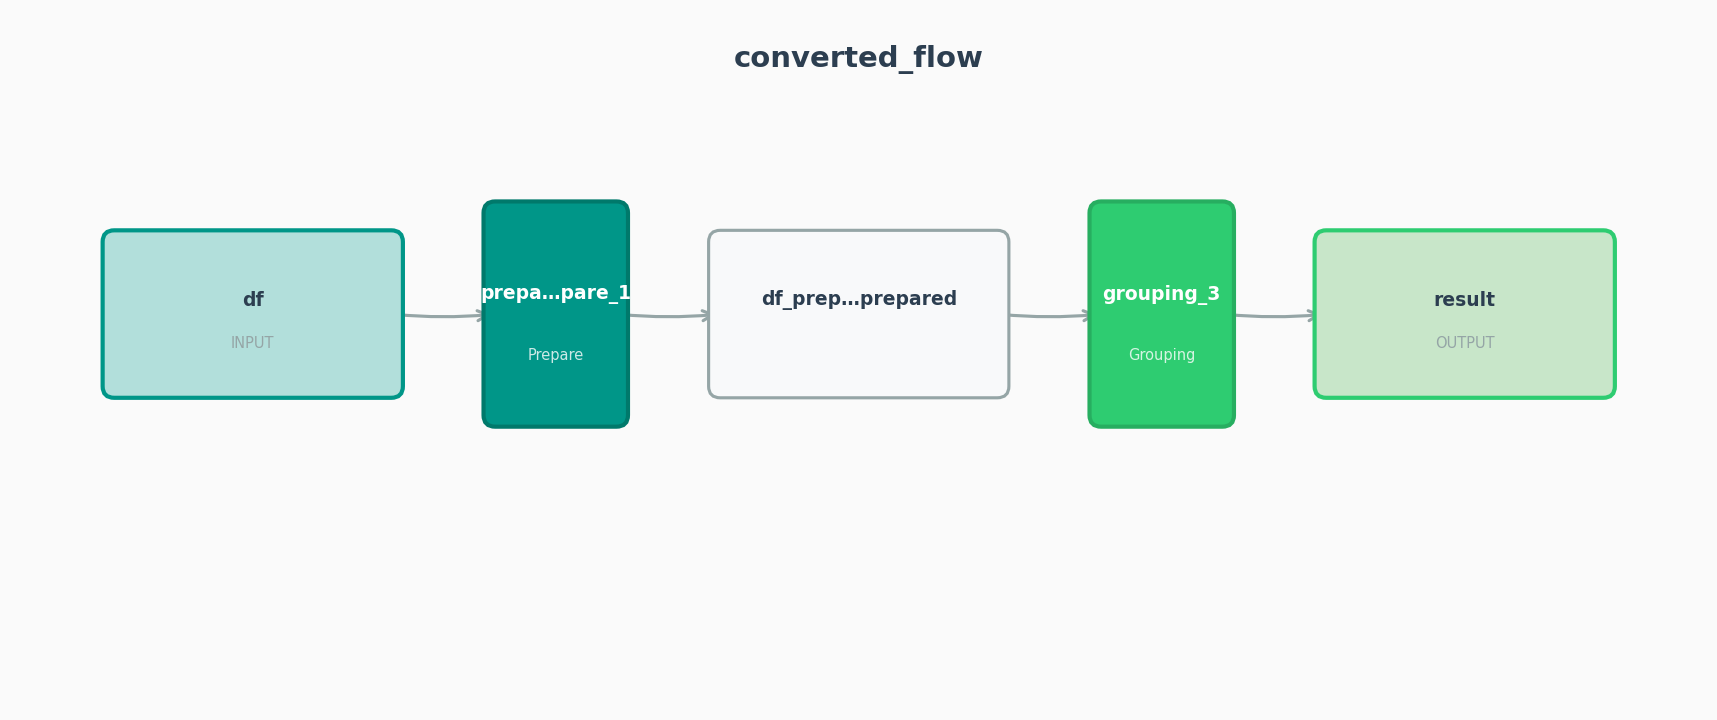

In [34]:
# PNG export - publication-quality diagram
from py2dataiku.visualizers import MatplotlibVisualizer
from IPython.display import Image, display

viz = MatplotlibVisualizer()
png_bytes = viz.render(flow)
display(Image(png_bytes))

In [35]:
# Mermaid visualization (GitHub/Notion compatible)
print(flow.visualize(format="mermaid"))

flowchart TD
    subgraph inputs[Input Datasets]
        D0[(df)]
    end
    subgraph outputs[Output Datasets]
        D2[(result)]
    end
    D1[(df_prepared_prepared)]
    R0{Prepare\n(3 steps)}
    R1{Grouping\n(1 aggs)}
    D0 --> R0
    R0 --> D1
    D1 --> R1
    R1 --> D2

    style D0 fill:#e1f5fe
    style D2 fill:#c8e6c9
    style R0 fill:#fff3e0
    style R1 fill:#e8f5e9


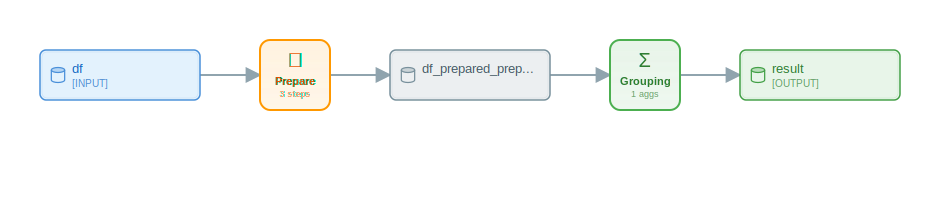

In [36]:
# SVG visualization renders inline in Jupyter
from IPython.display import SVG, display

svg_content = flow.visualize(format="svg")
display(SVG(svg_content))

In [37]:
# PlantUML visualization for technical specs
print(flow.visualize(format='plantuml'))

@startuml
!theme plain
skinparam backgroundColor #FAFAFA
skinparam defaultFontName Arial
skinparam defaultFontSize 12

' Dataset styles
skinparam rectangle {
  BackgroundColor<<input>> #E3F2FD
  BorderColor<<input>> #4A90D9
  FontColor<<input>> #1565C0
  BackgroundColor<<output>> #E8F5E9
  BorderColor<<output>> #43A047
  FontColor<<output>> #2E7D32
  BackgroundColor<<intermediate>> #ECEFF1
  BorderColor<<intermediate>> #78909C
  FontColor<<intermediate>> #455A64
}

' Recipe styles
skinparam card {
  BackgroundColor<<prepare>> #FFF3E0
  BorderColor<<prepare>> #FF9800
  BackgroundColor<<join>> #E3F2FD
  BorderColor<<join>> #2196F3
  BackgroundColor<<grouping>> #E8F5E9
  BorderColor<<grouping>> #4CAF50
  BackgroundColor<<split>> #FCE4EC
  BorderColor<<split>> #E91E63
  BackgroundColor<<python>> #E8EAF6
  BorderColor<<python>> #3F51B5
}

' Arrow style
skinparam arrow {
  Color #90A4AE
  Thickness 2
}

' Datasets
rectangle "df" <<input>> as df
rectangle "df_prepared_prepared" <<intermediate

## 5. FlowOptimizer

The `FlowOptimizer` can merge consecutive Prepare recipes, remove orphan intermediate datasets,
and generate recommendations for improving flow performance.

In [38]:
from py2dataiku.models.dataiku_flow import DataikuFlow
from py2dataiku.models.dataiku_recipe import DataikuRecipe, RecipeType
from py2dataiku.models.dataiku_dataset import DataikuDataset, DatasetType
from py2dataiku.optimizer.flow_optimizer import FlowOptimizer, OptimizationResult

# Build a flow with two consecutive Prepare recipes (suboptimal)
flow_before = DataikuFlow(name="unoptimized_flow")

# Datasets
flow_before.datasets = [
    DataikuDataset(name="raw_input", dataset_type=DatasetType.INPUT),
    DataikuDataset(name="intermediate_1", dataset_type=DatasetType.INTERMEDIATE),
    DataikuDataset(name="intermediate_2", dataset_type=DatasetType.INTERMEDIATE),
    DataikuDataset(name="final_output", dataset_type=DatasetType.OUTPUT),
]

# Recipe 1: first Prepare step
recipe1 = DataikuRecipe(
    name="prepare_step1",
    recipe_type=RecipeType.PREPARE,
    inputs=["raw_input"],
    outputs=["intermediate_1"],
    steps=[
        PrepareStep.remove_rows_on_empty(columns=["email"]),
        PrepareStep.string_transform("name", StringTransformerMode.TRIM),
    ],
)

# Recipe 2: second Prepare step (consecutive, mergeable)
recipe2 = DataikuRecipe(
    name="prepare_step2",
    recipe_type=RecipeType.PREPARE,
    inputs=["intermediate_1"],
    outputs=["intermediate_2"],
    steps=[
        PrepareStep.fill_empty("age", 0),
        PrepareStep.set_type("age", "bigint"),
    ],
)

# Recipe 3: Grouping (not mergeable with Prepare)
recipe3 = DataikuRecipe(
    name="compute_group_stats",
    recipe_type=RecipeType.GROUPING,
    inputs=["intermediate_2"],
    outputs=["final_output"],
    group_keys=["region"],
)

flow_before.recipes = [recipe1, recipe2, recipe3]

print("BEFORE OPTIMIZATION:")
print(f"  Recipes: {len(flow_before.recipes)}")
print(f"  Datasets: {len(flow_before.datasets)}")
for r in flow_before.recipes:
    step_info = f" ({len(r.steps)} steps)" if r.steps else ""
    print(f"  - {r.name} [{r.recipe_type.value}]{step_info}: {r.inputs} -> {r.outputs}")

BEFORE OPTIMIZATION:
  Recipes: 3
  Datasets: 4
  - prepare_step1 [prepare] (2 steps): ['raw_input'] -> ['intermediate_1']
  - prepare_step2 [prepare] (2 steps): ['intermediate_1'] -> ['intermediate_2']
  - compute_group_stats [grouping]: ['intermediate_2'] -> ['final_output']


In [39]:
# Run the optimizer
optimizer = FlowOptimizer()
optimized_flow = optimizer.optimize(flow_before, apply=True)
result = optimizer.last_result

print("AFTER OPTIMIZATION:")
print(f"  Recipes: {len(optimized_flow.recipes)}")
print(f"  Datasets: {len(optimized_flow.datasets)}")
for r in optimized_flow.recipes:
    step_info = f" ({len(r.steps)} steps)" if r.steps else ""
    print(f"  - {r.name} [{r.recipe_type.value}]{step_info}: {r.inputs} -> {r.outputs}")

print(f"\nOptimizationResult:")
print(f"  Recipes merged: {result.recipes_merged}")
print(f"  Datasets removed: {result.datasets_removed}")
print(f"  Log:")
for entry in result.log:
    print(f"    - {entry}")

AFTER OPTIMIZATION:
  Recipes: 2
  Datasets: 3
  - prepare_merged_prepare_step1 [prepare] (4 steps): ['raw_input'] -> ['intermediate_2']
  - compute_group_stats [grouping]: ['intermediate_2'] -> ['final_output']

OptimizationResult:
  Recipes merged: 1
  Datasets removed: 1
  Log:
    - Merged 'prepare_step1' + 'prepare_step2' -> 'prepare_merged_prepare_step1'
    - Removed intermediate dataset 'intermediate_1'


### Before vs After: Visual Comparison

Let's see the flow structure before optimization.

In [40]:
# Visualize the flow BEFORE optimization (rebuild the unoptimized flow)
flow_viz_before = DataikuFlow(name='before_optimization')
flow_viz_before.datasets = [
    DataikuDataset(name='raw_input', dataset_type=DatasetType.INPUT),
    DataikuDataset(name='intermediate_1', dataset_type=DatasetType.INTERMEDIATE),
    DataikuDataset(name='intermediate_2', dataset_type=DatasetType.INTERMEDIATE),
    DataikuDataset(name='final_output', dataset_type=DatasetType.OUTPUT),
]
flow_viz_before.recipes = [
    DataikuRecipe(
        name='prepare_step1', recipe_type=RecipeType.PREPARE,
        inputs=['raw_input'], outputs=['intermediate_1'],
        steps=[PrepareStep.remove_rows_on_empty(columns=['email']),
               PrepareStep.string_transform('name', StringTransformerMode.TRIM)],
    ),
    DataikuRecipe(
        name='prepare_step2', recipe_type=RecipeType.PREPARE,
        inputs=['intermediate_1'], outputs=['intermediate_2'],
        steps=[PrepareStep.fill_empty('age', 0), PrepareStep.set_type('age', 'bigint')],
    ),
    DataikuRecipe(
        name='compute_group_stats', recipe_type=RecipeType.GROUPING,
        inputs=['intermediate_2'], outputs=['final_output'],
        group_keys=['region'],
    ),
]

print('=== BEFORE OPTIMIZATION ===')
print(flow_viz_before.visualize(format='ascii'))

=== BEFORE OPTIMIZATION ===
════════════════════════════════════════════════════════════════════════════════
                       DATAIKU FLOW: before_optimization  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 raw_input      │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 2 steps      │
                                └──────────────┘

                                       │
                                       ▼

                              ┌──────────────────┐
                              │ 📊 intermediate_1 │
                              └

In [41]:
# Visualize the flow AFTER optimization
print('=== AFTER OPTIMIZATION ===')
print(optimized_flow.visualize(format='ascii'))

# Also show as Mermaid for comparison
print('\nMermaid (after optimization):')
print(optimized_flow.visualize(format='mermaid'))

=== AFTER OPTIMIZATION ===
════════════════════════════════════════════════════════════════════════════════
                         DATAIKU FLOW: unoptimized_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 raw_input      │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 4 steps      │
                                └──────────────┘

                                       │
                                       ▼

                              ┌──────────────────┐
                              │ 📊 intermediate_2 │
                              └──

In [42]:
# OptimizationResult as a dict
print("Result dict:", result.to_dict())

# Optimization notes stored on the flow
print("\nFlow optimization notes:")
for note in optimized_flow.optimization_notes:
    print(f"  - {note}")

Result dict: {'recipes_merged': 1, 'datasets_removed': 1, 'filters_pushed_down': 0, 'log': ["Merged 'prepare_step1' + 'prepare_step2' -> 'prepare_merged_prepare_step1'", "Removed intermediate dataset 'intermediate_1'"]}

Flow optimization notes:
  - Merged 'prepare_step1' + 'prepare_step2' -> 'prepare_merged_prepare_step1'
  - Removed intermediate dataset 'intermediate_1'


In [43]:
# Recommendation-only mode (no changes applied)
flow_recommend = DataikuFlow(name="recommend_test")
flow_recommend.datasets = [
    DataikuDataset(name="src", dataset_type=DatasetType.INPUT),
    DataikuDataset(name="mid", dataset_type=DatasetType.INTERMEDIATE),
    DataikuDataset(name="dst", dataset_type=DatasetType.OUTPUT),
]
flow_recommend.recipes = [
    DataikuRecipe(
        name="prep_a", recipe_type=RecipeType.PREPARE,
        inputs=["src"], outputs=["mid"],
        steps=[PrepareStep.fill_empty("x", 0)],
    ),
    DataikuRecipe(
        name="prep_b", recipe_type=RecipeType.PREPARE,
        inputs=["mid"], outputs=["dst"],
        steps=[PrepareStep.set_type("x", "bigint")],
    ),
]

opt2 = FlowOptimizer()
opt2.optimize(flow_recommend, apply=False)  # recommendation only

print(f"Recipes unchanged: {len(flow_recommend.recipes)} (still 2)")
print(f"Recommendations generated: {len(flow_recommend.recommendations)}")
for rec in flow_recommend.recommendations:
    print(f"  [{rec.priority}] {rec.type}: {rec.message}")
    if rec.action:
        print(f"    Action: {rec.action}")

Recipes unchanged: 2 (still 2)
Recommendations generated: 1
  [MEDIUM] CONSOLIDATION: Found 1 consecutive Prepare recipes that could be merged
    Action: Combine steps into single Prepare recipe


### Optimizer via convert(): Before vs After Recipe Count

The `convert(code, optimize=True)` flag now actually merges consecutive Prepare recipes
and removes orphan intermediate datasets. Compare the recipe counts:

In [44]:
# Before/after optimizer comparison using convert() directly
opt_code = """
import pandas as pd
df = pd.read_csv('data.csv')
df = df.fillna(0)
df = df.rename(columns={'amt': 'amount'})
df = df.dropna()
df['amount'] = df['amount'].astype(float)
result = df.groupby('category').agg({'amount': 'sum'})
"""

flow_unopt = convert(opt_code, optimize=False)
flow_opt = convert(opt_code, optimize=True)

print("=== BEFORE optimization (optimize=False) ===")
print(f"  Total recipes: {len(flow_unopt.recipes)}")
for r in flow_unopt.recipes:
    steps_info = f" ({len(r.steps)} steps)" if r.steps else ""
    print(f"    {r.recipe_type.value}: {r.name}{steps_info}")

print(f"\n=== AFTER optimization (optimize=True) ===")
print(f"  Total recipes: {len(flow_opt.recipes)}")
for r in flow_opt.recipes:
    steps_info = f" ({len(r.steps)} steps)" if r.steps else ""
    print(f"    {r.recipe_type.value}: {r.name}{steps_info}")

print(f"\nOptimization notes: {flow_opt.optimization_notes}")

=== BEFORE optimization (optimize=False) ===
  Total recipes: 3
    prepare: prepare_1 (3 steps)
    prepare: prepare_2 (1 steps)
    grouping: grouping_3

=== AFTER optimization (optimize=True) ===
  Total recipes: 2
    prepare: prepare_merged_prepare_1 (4 steps)
    grouping: grouping_3

Optimization notes: ["Merged 'prepare_1' + 'prepare_2' -> 'prepare_merged_prepare_1'", "Removed intermediate dataset 'df_prepared'", 'prepare: 1 recipe(s)', 'grouping: 1 recipe(s)']


## 6. Flow Validation

The `flow.validate()` method performs structural validation using DAG analysis.
It checks for cycles, orphan datasets, missing references, disconnected subgraphs,
and Python fallback recipes.

In [45]:
# Validate a well-formed flow
good_flow = DataikuFlow(name="valid_flow")
good_flow.datasets = [
    DataikuDataset(name="input_ds", dataset_type=DatasetType.INPUT),
    DataikuDataset(name="output_ds", dataset_type=DatasetType.OUTPUT),
]
good_flow.recipes = [
    DataikuRecipe(
        name="transform", recipe_type=RecipeType.PREPARE,
        inputs=["input_ds"], outputs=["output_ds"],
        steps=[PrepareStep.fill_empty("x", 0)],
    )
]

result = good_flow.validate()
print("Valid flow:")
print(f"  valid: {result['valid']}")
print(f"  errors: {result['errors']}")
print(f"  warnings: {result['warnings']}")
print(f"  info: {result['info']}")

Valid flow:
  valid: True
  errors: []
  warnings: []
  info: []


In [46]:
# Validate a flow with issues
bad_flow = DataikuFlow(name="problematic_flow")

# Add an orphan dataset (not connected to any recipe)
bad_flow.datasets = [
    DataikuDataset(name="input_ds", dataset_type=DatasetType.INPUT),
    DataikuDataset(name="orphan_ds", dataset_type=DatasetType.INPUT),
    DataikuDataset(name="output_ds", dataset_type=DatasetType.OUTPUT),
    DataikuDataset(name="branch_out", dataset_type=DatasetType.OUTPUT),
]

# Recipes forming two disconnected subgraphs + a Python fallback
bad_flow.recipes = [
    DataikuRecipe(
        name="transform", recipe_type=RecipeType.PREPARE,
        inputs=["input_ds"], outputs=["output_ds"],
        steps=[PrepareStep.fill_empty("x", 0)],
    ),
    DataikuRecipe(
        name="py_fallback", recipe_type=RecipeType.PYTHON,
        inputs=["branch_out"], outputs=[],
        code="custom_transform(df)",
    ),
]

result = bad_flow.validate()
print("Problematic flow:")
print(f"  valid: {result['valid']}")
print(f"  errors ({len(result['errors'])}):")
for e in result['errors']:
    print(f"    [{e['type']}] {e['message']}")
print(f"  warnings ({len(result['warnings'])}):")
for w in result['warnings']:
    print(f"    [{w['type']}] {w['message']}")
print(f"  info ({len(result['info'])}):")
for i in result['info']:
    print(f"    [{i['type']}] {i['message']}")

Problematic flow:
  valid: True
  errors (0):
  warnings (2):
    [ORPHAN_DATASET] Dataset 'orphan_ds' is not connected to any recipe
    [DISCONNECTED_FLOW] Flow has 3 disconnected subgraphs
  info (1):
    [PYTHON_FALLBACK] Recipe 'py_fallback' requires Python recipe


## 7. Column Lineage

The `flow.get_column_lineage()` method traces a column backward through the flow's recipes
to find its origin dataset and any transformations applied along the way.

In [47]:
from py2dataiku.models.dataiku_flow import DataikuFlow, ColumnLineage

# Build a flow with trackable column transformations
lineage_flow = DataikuFlow(name="lineage_demo")
lineage_flow.datasets = [
    DataikuDataset(name="source_data", dataset_type=DatasetType.INPUT),
    DataikuDataset(name="cleaned_data", dataset_type=DatasetType.INTERMEDIATE),
    DataikuDataset(name="final_data", dataset_type=DatasetType.OUTPUT),
]

# Prepare recipe with several column transformations
lineage_flow.recipes = [
    DataikuRecipe(
        name="clean_step",
        recipe_type=RecipeType.PREPARE,
        inputs=["source_data"],
        outputs=["cleaned_data"],
        steps=[
            PrepareStep.fill_empty("revenue", 0),
            PrepareStep.string_transform("name", StringTransformerMode.UPPERCASE),
        ],
    ),
    DataikuRecipe(
        name="finalize",
        recipe_type=RecipeType.PREPARE,
        inputs=["cleaned_data"],
        outputs=["final_data"],
        steps=[
            PrepareStep(
                processor_type=ProcessorType.ROUND_COLUMN,
                params={"column": "revenue", "precision": 2},
            ),
        ],
    ),
]

# Trace the "revenue" column
lineage = lineage_flow.get_column_lineage("revenue", dataset="final_data")
print(f"Column: {lineage.column}")
print(f"Final dataset: {lineage.final_dataset}")
print(f"Origin dataset: {lineage.origin_dataset}")
print(f"Origin column: {lineage.origin_column}")
print(f"Transformations ({len(lineage.transformations)}):")
for t in lineage.transformations:
    print(f"  - {t}")

Column: revenue
Final dataset: final_data
Origin dataset: source_data
Origin column: revenue
Transformations (2):
  - {'type': 'FillEmptyWithValue', 'recipe': 'clean_step', 'column': 'revenue'}
  - {'type': 'Round', 'recipe': 'finalize', 'column': 'revenue'}


In [48]:
# Lineage as a dict (for serialization)
print("Lineage dict:")
import json
print(json.dumps(lineage.to_dict(), indent=2))

Lineage dict:
{
  "column": "revenue",
  "final_dataset": "final_data",
  "origin": {
    "dataset": "source_data",
    "column": "revenue"
  },
  "transformations": [
    {
      "type": "FillEmptyWithValue",
      "recipe": "clean_step",
      "column": "revenue"
    },
    {
      "type": "Round",
      "recipe": "finalize",
      "column": "revenue"
    }
  ]
}


In [49]:
# Trace the "name" column through a different transformation path
name_lineage = lineage_flow.get_column_lineage("name", dataset="final_data")
print(f"Column 'name' lineage:")
print(f"  Origin: {name_lineage.origin_dataset}.{name_lineage.origin_column}")
print(f"  Final:  {name_lineage.final_dataset}.{name_lineage.column}")
print(f"  Transformations: {name_lineage.transformations}")

Column 'name' lineage:
  Origin: source_data.name
  Final:  final_data.name
  Transformations: [{'type': 'StringTransformer', 'recipe': 'clean_step', 'column': 'name'}]


## 8. End-to-End Example: Convert, Analyze, Optimize

Putting it all together: convert Python code, inspect the DAG, validate, and optimize.

In [50]:
from py2dataiku import convert
from py2dataiku.optimizer.flow_optimizer import FlowOptimizer

# A more complex pipeline
pipeline_code = """
import pandas as pd
import numpy as np

# Load and clean
df = pd.read_csv('transactions.csv')
df = df.dropna(subset=['amount', 'customer_id'])
df = df.rename(columns={'amt': 'amount', 'cust_id': 'customer_id'})
df['amount'] = df['amount'].astype(float)

# Aggregate by customer
summary = df.groupby('customer_id').agg({'amount': 'sum', 'date': 'count'})
summary = summary.rename(columns={'date': 'transaction_count'})

# Top customers
top = summary.nlargest(100, 'amount')
"""

flow = convert(pipeline_code, optimize=False)
print("Flow summary (before optimization):")
print(flow.get_summary())

Flow summary (before optimization):
Flow: converted_flow
Source: unknown
Generated: 2026-04-25T10:31:15.941507

Datasets: 6
  - Input: 1
  - Intermediate: 5
  - Output: 0

Recipes: 5
  - grouping: 1
  - prepare: 3
  - topn: 1


In [51]:
# DAG analysis
dag = flow.graph
print(f"DAG: {dag}")
print(f"Roots: {dag.get_roots()}")
print(f"Leaves: {dag.get_leaves()}")
print(f"Cycles: {dag.detect_cycles()}")
print(f"Components: {len(dag.find_disconnected_subgraphs())}")

DAG: FlowGraph(nodes=11, edges=10)
Roots: ['df']
Leaves: ['df_prepared_prepared', 'top']
Cycles: []
Components: 1


In [52]:
# Validate
validation = flow.validate()
print(f"Valid: {validation['valid']}")
if validation['warnings']:
    print("Warnings:")
    for w in validation['warnings']:
        print(f"  - {w}")

Valid: True


In [53]:
# Optimize
optimizer = FlowOptimizer()
optimizer.optimize(flow, apply=True)
result = optimizer.last_result

print("Optimization result:")
print(f"  Recipes merged: {result.recipes_merged}")
print(f"  Datasets removed: {result.datasets_removed}")
for entry in result.log:
    print(f"  - {entry}")

print(f"\nFlow summary (after optimization):")
print(flow.get_summary())

Optimization result:
  Recipes merged: 1
  Datasets removed: 1
  - Merged 'prepare_1' + 'prepare_2' -> 'prepare_merged_prepare_1'
  - Removed intermediate dataset 'df_prepared'

Flow summary (after optimization):
Flow: converted_flow
Source: unknown
Generated: 2026-04-25T10:31:15.941507

Datasets: 5
  - Input: 1
  - Intermediate: 4
  - Output: 0

Recipes: 4
  - grouping: 1
  - prepare: 2
  - topn: 1

Optimization Notes:
  - Merged 'prepare_1' + 'prepare_2' -> 'prepare_merged_prepare_1'
  - Removed intermediate dataset 'df_prepared'


In [54]:
# Visualize the optimized end-to-end flow
print('=== Optimized Pipeline (ASCII) ===')
print(flow.visualize(format='ascii'))

print('\n=== Optimized Pipeline (Mermaid) ===')
print(flow.visualize(format='mermaid'))

print('\n=== Optimized Pipeline (PlantUML) ===')
print(flow.visualize(format='plantuml'))

=== Optimized Pipeline (ASCII) ===
════════════════════════════════════════════════════════════════════════════════
                          DATAIKU FLOW: converted_flow  
════════════════════════════════════════════════════════════════════════════════

                              ┌──────────────────┐
                              │ 📊 df             │
                             │    [INPUT]        │
                              └──────────────────┘

                                       │
                                       ▼

                                ┌──────────────┐
                               │   ⚙ PREPARE   │
                                │ ──────────── │
                                │ 3 steps      │
                                └──────────────┘

                                       │
                                       ▼

                           ┌────────────────────────┐
                           │ 📊 df_prepared_prepared │
                    

---
## 9. HTML and Interactive Visualization

Beyond text-based formats, py-iku supports HTML (canvas-based) and Interactive
(pan/zoom/search) visualization formats.

In [55]:
from IPython.display import HTML

# HTML visualization
html_content = flow.visualize(format="html")
print(f"HTML output: {len(html_content)} characters")
print(f"Preview: {html_content[:150]}...")

# Interactive visualization with pan/zoom/search
interactive_content = flow.visualize(format="interactive")
print(f"\nInteractive output: {len(interactive_content)} characters")
print(f"Preview: {interactive_content[:150]}...")

HTML output: 14245 characters
Preview: <!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <tit...

Interactive output: 36860 characters
Preview: <!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <tit...


---
## 10. Theme Switching: DATAIKU_LIGHT vs DATAIKU_DARK

Apply different themes to the same flow to see the visual difference.

=== DATAIKU_LIGHT ===


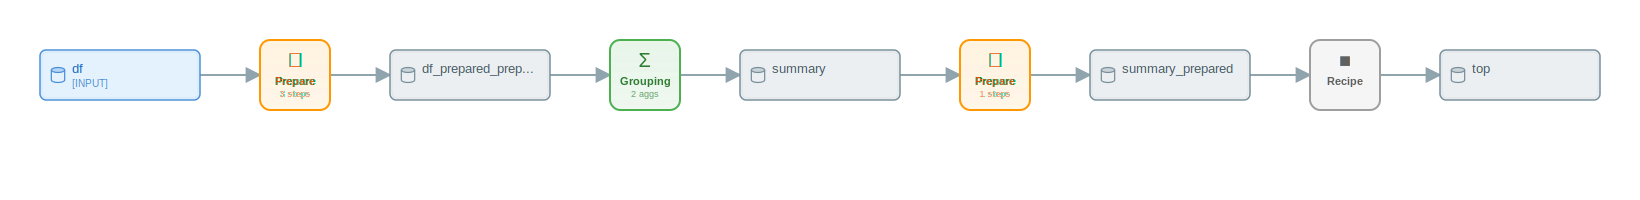

In [56]:
from IPython.display import SVG, display
from py2dataiku.visualizers import DATAIKU_LIGHT, DATAIKU_DARK

# Light theme (default)
print("=== DATAIKU_LIGHT ===")
light_svg = flow.visualize(format="svg", theme=DATAIKU_LIGHT)
display(SVG(light_svg))

=== DATAIKU_DARK ===


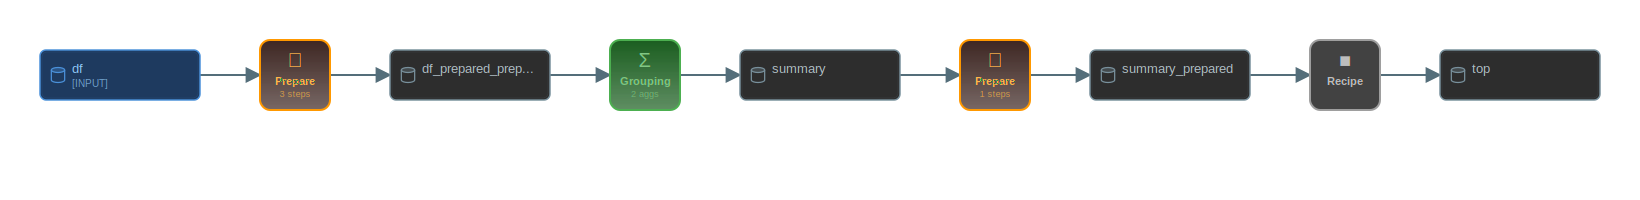

In [57]:
# Dark theme
print("=== DATAIKU_DARK ===")
dark_svg = flow.visualize(format="svg", theme=DATAIKU_DARK)
display(SVG(dark_svg))

---
## 11. Visualization Export Patterns

Visualizations can be saved to files for documentation, sharing, or integration
into reports.

In [58]:
import tempfile
import os

# Export visualizations to files
with tempfile.TemporaryDirectory() as tmpdir:
    # SVG export
    svg_path = os.path.join(tmpdir, "flow.svg")
    with open(svg_path, "w") as f:
        f.write(flow.visualize(format="svg"))
    print(f"SVG saved: {os.path.getsize(svg_path)} bytes")

    # HTML export
    html_path = os.path.join(tmpdir, "flow.html")
    with open(html_path, "w") as f:
        f.write(flow.visualize(format="html"))
    print(f"HTML saved: {os.path.getsize(html_path)} bytes")

    # Mermaid export (can be embedded in Markdown)
    md_path = os.path.join(tmpdir, "flow.md")
    with open(md_path, "w") as f:
        f.write("```mermaid\n")
        f.write(flow.visualize(format="mermaid"))
        f.write("\n```\n")
    print(f"Mermaid MD saved: {os.path.getsize(md_path)} bytes")

    # Interactive export
    interactive_path = os.path.join(tmpdir, "flow_interactive.html")
    with open(interactive_path, "w") as f:
        f.write(flow.visualize(format="interactive"))
    print(f"Interactive saved: {os.path.getsize(interactive_path)} bytes")

    print("\nAll visualization files exported successfully.")

SVG saved: 13372 bytes
HTML saved: 14250 bytes
Mermaid MD saved: 516 bytes
Interactive saved: 36889 bytes

All visualization files exported successfully.


## Summary

This notebook covered py2dataiku's advanced capabilities:

| Feature | Key Classes/Methods | Purpose |
|---------|--------------------|---------|
| **ProcessorCatalog** | `list_processors()`, `get_processor()`, `list_categories()` | Browse 100+ Dataiku processor types with metadata |
| **PrepareStep** | `ProcessorType`, factory methods, `to_dict()`/`from_dict()` | Create individual transformation steps |
| **PrepareSettings** | `PrepareSettings(steps=[...])` | Compose multi-step Prepare recipes |
| **FlowGraph** | `topological_sort()`, `detect_cycles()`, `find_disconnected_subgraphs()` | DAG analysis of flow structure |
| **FlowOptimizer** | `optimize()`, `OptimizationResult` | Merge recipes, remove orphans, generate recommendations |
| **Validation** | `flow.validate()` | Structural checks: cycles, orphans, missing refs |
| **Column Lineage** | `flow.get_column_lineage()` | Trace columns through transformations to their origin |